# Retail Sales Insight: Turning Transactions into Business Decisions

An interactive retail sales analytics project that transforms
transactional data into actionable business insights.


# 🛒 Deaz & Co Sales Analytics

# 1. 📖 Data Understanding

### Project Overview

This notebook aims to understand the structure, quality, and characteristics of the Deaz & Co sales dataset before performing data cleaning and exploratory data analysis (EDA).

---

**Author:** Deaz

**Tools:**
- Python
- Pandas
- NumPy
- Jupyter Notebook

**Dataset**
Deaz & Co Sales Dataset

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [5]:
#load dataset

df = pd.read_excel(
    "../dataset/Deaz Co Analytics.xlsx",
)


In [6]:
#check
df.shape

(8087, 17)

## 🎯 Objective

The objective of this notebook is to understand the dataset before conducting further analysis.

The analysis focuses on:

- Dataset structure
- Data types
- Missing values
- Duplicate records
- Descriptive statistics
- Initial observations

In [30]:
#dataset dimensions

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 8,087
Columns : 17


# Data Information

Melihat tipe data setiap kolom serta memastikan apakah terdapat nilai kosong.

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8087 entries, 0 to 8086
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       8087 non-null   str           
 1   Order Date     8087 non-null   datetime64[us]
 2   Customer Name  8007 non-null   str           
 3   Country        8087 non-null   str           
 4   State          8087 non-null   str           
 5   City           8007 non-null   str           
 6   Region         8087 non-null   str           
 7   Segment        8087 non-null   str           
 8   Ship Mode      8087 non-null   str           
 9   Category       8087 non-null   str           
 10  Sub-Category   8087 non-null   str           
 11  Product Name   8087 non-null   str           
 12  Discount       8087 non-null   float64       
 13  Sales          8087 non-null   int64         
 14  Profit         8087 non-null   int64         
 15  Quantity       8087 non-null   i

# Statistical Summary

Melihat ringkasan statistik untuk memahami distribusi data numerik dan kategorikal.

In [32]:
df.describe()

,Order Date,Discount,Sales,Profit,Quantity
count,8087,"8,087.00","8,087.00","8,087.00","8,087.00"
mean,2013-04-19 17:52:07.241251,0.12,"1,011,806.58","162,812.92",3.78
min,2011-01-01 00:00:00,0.00,"4,000.00","-1,778,890.00",1.00
25%,2012-06-08 12:00:00,0.00,"64,000.00","9,827.00",2.00
50%,2013-06-12 00:00:00,0.00,"142,500.00","22,969.00",3.00
75%,2014-04-30 12:00:00,0.10,"870,000.00","133,144.50",5.00
max,2014-12-31 00:00:00,0.85,"38,520,000.00","5,337,552.00",14.00
std,NaN,0.19,"2,253,457.30","371,013.28",2.21


In [23]:
df.describe(include="object")

C:\Users\deazc\AppData\Local\Temp\ipykernel_27096\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Order ID,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name
count,8047,8047,8047,8047,8047,8047,8047,8047,8047,8047,8047
unique,4117,17,1,10,14,3,3,4,3,17,17
top,AZ-2014-7040665,Bagus Setiawan,Indonesia,Jawa Barat,Medan,Barat,Consumer,Economy,Office Supplies,Art,Spidol Permanen
freq,11,510,8047,2300,621,4039,4174,4862,5286,1152,774


# Missing Values

Mengidentifikasi kolom yang memiliki data kosong.

In [24]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Column","Missing"]

missing["Percentage"] = (
    missing["Missing"] /
    len(df)
    *100
)

missing

,Column,Missing,Percentage
0,Order ID,0,0.00
1,Order Date,0,0.00
2,Customer Name,0,0.00
3,Country,0,0.00
4,State,0,0.00
5,City,0,0.00
6,Region,0,0.00
7,Segment,0,0.00
8,Ship Mode,0,0.00
9,Category,0,0.00


# Duplicate Records

In [25]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


Berapa Customer ?
Berapa Product ?
Berapa Kota ?
Berapa Order ?

In [26]:
df.nunique().sort_values(ascending=False)

Profit           7614
Order ID         4117
Sales            2005
Order Date       1214
Customer Name      17
Product Name       17
Sub-Category       17
City               14
Quantity           14
Discount           14
State              10
Ship Mode           4
Region              3
Category            3
Segment             3
Feedback?           2
Country             1
dtype: int64

Hasil Obeservasi

Dataset terdiri dari 8.048 transaksi.
Tidak ditemukan duplicate.
Mayoritas kolom telah memiliki tipe data yang sesuai.
Dataset siap memasuki tahap Data Cleaning.

## Next Step

Pada notebook berikutnya (`02_Data_Cleaning`), akan dilakukan:

- Identifikasi dan penanganan missing values.
- Pemeriksaan duplicate records.
- Validasi tipe data.
- Analisis outlier.
- Standardisasi data kategorikal.

# 2. Data Cleaning

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data, menemukan pola, tren, dan hubungan antar variabel. Hasil analisis ini digunakan untuk memperoleh insight bisnis yang dapat mendukung pengambilan keputusan.

Cek Struktur Data

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8087 entries, 0 to 8086
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       8087 non-null   str           
 1   Order Date     8087 non-null   datetime64[us]
 2   Customer Name  8007 non-null   str           
 3   Country        8087 non-null   str           
 4   State          8087 non-null   str           
 5   City           8007 non-null   str           
 6   Region         8087 non-null   str           
 7   Segment        8087 non-null   str           
 8   Ship Mode      8087 non-null   str           
 9   Category       8087 non-null   str           
 10  Sub-Category   8087 non-null   str           
 11  Product Name   8087 non-null   str           
 12  Discount       8087 non-null   float64       
 13  Sales          8087 non-null   int64         
 14  Profit         8087 non-null   int64         
 15  Quantity       8087 non-null   i

In [34]:
df.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
0,BN-2011-7407039,2011-01-01,Fajar Nugroho,Indonesia,Bali,Denpasar,Timur,Home Office,Economy Plus,Office Supplies,Paper,Buku Tulis A5,0.50,39000,7679,3,False
1,AZ-2011-9050313,2011-01-03,Fajar Nugroho,Indonesia,Jawa Timur,Malang,Tengah,Consumer,Economy,Furniture,Bookcases,Meja Kerja,0.00,9275000,2287011,7,True
2,AZ-2011-6674300,2011-01-04,Nurul Hidayah,Indonesia,Kalimantan Timur,Balikpapan,Timur,Consumer,Economy,Office Supplies,Art,Kertas HVS A4,0.00,141000,14023,3,True
3,BN-2011-2819714,2011-01-04,Rizky Hidayat,Indonesia,Jawa Timur,Malang,Tengah,Corporate,Economy,Office Supplies,Art,Kertas HVS A4,0.50,48500,11246,2,True
4,BN-2011-2819714,2011-01-04,Ahmad Fauzi,Indonesia,Jawa Barat,Bandung,Barat,Corporate,Economy,Office Supplies,Storage,Map Plastik,0.50,10000,2445,2,True


In [35]:
df.tail()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
8082,BN-2012-1840442,2012-09-17,Ahmad Fauzi,Indonesia,Sumatera Selatan,Palembang,Barat,Home Office,Immediate,Office Supplies,Storage,Map Plastik,0.10,51300,8499,3,True
8083,AZ-2013-5932628,2013-06-28,Ilham Ramadhan,Indonesia,DKI Jakarta,Jakarta,Barat,Home Office,Economy,Furniture,Furnishings,Rak Penyimpanan,0.00,3100000,499316,2,True
8084,BN-2014-4912801,2014-12-29,Yusuf Maulana,Indonesia,DKI Jakarta,Jakarta,Barat,Corporate,Priority,Office Supplies,Art,Map Plastik,0.50,21500,4666,1,False
8085,BN-2013-9140606,2013-01-16,Bagus Setiawan,Indonesia,Jawa Barat,Bogor,Barat,Consumer,Economy,Technology,Accessories,Headset,0.50,770000,159483,4,False
8086,AZ-2014-8735182,2014-12-04,Nurul Hidayah,Indonesia,DKI Jakarta,Jakarta,Barat,Home Office,Immediate,Office Supplies,Paper,Buku Tulis A5,0.00,432000,69254,8,False


In [36]:
df.describe(include="all")

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
count,8087,8087,8007,8087,8087,8007,8087,8087,8087,8087,8087,8087,"8,087.00","8,087.00","8,087.00","8,087.00",7846
unique,4117,NaN,17,1,10,14,3,3,4,3,17,120,NaN,NaN,NaN,NaN,2
top,AZ-2014-7040665,NaN,Bagus Setiawan,Indonesia,Jawa Barat,Medan,Barat,Consumer,Economy,Office Supplies,Art,Spidol Permanen,NaN,NaN,NaN,NaN,False
freq,11,NaN,509,8087,2310,618,4059,4185,4884,5308,1156,763,NaN,NaN,NaN,NaN,3927
mean,NaN,2013-04-19 17:52:07.241251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.12,"1,011,806.58","162,812.92",3.78,NaN
min,NaN,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"4,000.00","-1,778,890.00",1.00,NaN
25%,NaN,2012-06-08 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"64,000.00","9,827.00",2.00,NaN
50%,NaN,2013-06-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"142,500.00","22,969.00",3.00,NaN
75%,NaN,2014-04-30 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,"870,000.00","133,144.50",5.00,NaN
max,NaN,2014-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.85,"38,520,000.00","5,337,552.00",14.00,NaN


In [37]:
#missing values

#df.isnull().sum()

In [38]:
#persentase missing values

missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Persentase": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing", ascending=False)

,Missing,Persentase
Feedback?,241,2.98
City,80,0.99
Customer Name,80,0.99
Order ID,0,0.00
Country,0,0.00
State,0,0.00
Region,0,0.00
Segment,0,0.00
Order Date,0,0.00
Ship Mode,0,0.00


In [39]:
#check duplicate

df.duplicated().sum()

np.int64(40)

In [40]:
#delete duplicate

df = df.drop_duplicates()

In [41]:
#check data types

df.dtypes

Order ID                    str
Order Date       datetime64[us]
Customer Name               str
Country                     str
State                       str
City                        str
Region                      str
Segment                     str
Ship Mode                   str
Category                    str
Sub-Category                str
Product Name                str
Discount                float64
Sales                     int64
Profit                    int64
Quantity                  int64
Feedback?                object
dtype: object

In [42]:
#memastikan tidak ada typo

for col in df.select_dtypes(include="object"):
    print("="*50)
    print(col)
    print(df[col].unique()[:20])

Order ID
<ArrowStringArray>
['BN-2011-7407039', 'AZ-2011-9050313', 'AZ-2011-6674300', 'BN-2011-2819714',
  'AZ-2011-617423', 'AZ-2011-2918397', 'BN-2011-3248724', 'AZ-2011-6712797',
 'AZ-2011-4827146', 'AZ-2011-6439906', 'AZ-2011-7053593', 'AZ-2011-5702370',
 'AZ-2011-9927716', 'AZ-2011-2222024', 'BN-2011-4913858', 'BN-2011-2807470',
 'AZ-2011-5960662', 'AZ-2011-7675351', 'BN-2011-3770060', 'AZ-2011-7419210']
Length: 20, dtype: str
Customer Name
<ArrowStringArray>
[    'Fajar Nugroho',     'Nurul Hidayah',     'Rizky Hidayat',
       'Ahmad Fauzi',    'Bagus Setiawan',      'Andi Pratama',
 'Citra Ayuningtyas',    'Ilham Ramadhan',      'Farhan Akbar',
       'Siti Aisyah',    'Putri Maharani',       'Rina Kurnia',
      'Nabila Putri',      'Budi Santoso',     'Yusuf Maulana',
      'Dewi Lestari',                 nan,      'Agus Saputra']
Length: 18, dtype: str
Country
<ArrowStringArray>
['Indonesia']
Length: 1, dtype: str
State
<ArrowStringArray>
[            'Bali',       'Jawa Tim

C:\Users\deazc\AppData\Local\Temp\ipykernel_27096\772102112.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [43]:
# karena ada missing value nama customer, kota customer , dan feedback kosong, kita lakukan pendekatan menggunakan fillna

df["Customer Name"] = df["Customer Name"].fillna("Unknown")

df["City"] = df["City"].fillna("Unknown")

df["Feedback?"] = df["Feedback?"].fillna(False)

In [45]:
#Simpan hasil cleaning

df.to_csv("Deaz Co Analytics Clean.csv", index=False)

# Kesimpulan Data Cleaning

Proses Data Cleaning dilakukan untuk memastikan kualitas data sebelum memasuki tahap Exploratory Data Analysis (EDA). Beberapa tahapan yang telah dilakukan meliputi:

- Memahami struktur dataset menggunakan `info()` dan `describe()`.
- Mengidentifikasi serta menangani missing values sesuai karakteristik masing-masing kolom.
- Memeriksa dan menghapus data duplikat apabila ditemukan.
- Memverifikasi kesesuaian tipe data pada setiap kolom.
- Memeriksa inkonsistensi data kategorikal, seperti typo atau perbedaan penulisan.
- Melakukan pemeriksaan terhadap outlier sebagai bahan pertimbangan dalam analisis.

Setelah proses Data Cleaning selesai, dataset memiliki kualitas yang lebih baik, lebih konsisten, dan siap digunakan untuk tahap Exploratory Data Analysis (EDA) guna memperoleh insight bisnis yang relevan.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data, menemukan pola, tren, dan hubungan antar variabel. Hasil analisis ini digunakan untuk memperoleh insight bisnis yang dapat mendukung pengambilan keputusan.

## 3.1 Statistik Deskriptif

Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai distribusi data numerik, seperti Sales, Profit, Discount, dan Quantity.

In [46]:
df.describe()

,Order Date,Discount,Sales,Profit,Quantity
count,8047,"8,047.00","8,047.00","8,047.00","8,047.00"
mean,2013-04-19 12:25:40.748105,0.12,"1,005,193.24","161,908.70",3.77
min,2011-01-01 00:00:00,0.00,"4,000.00","-1,778,890.00",1.00
25%,2012-06-08 00:00:00,0.00,"64,000.00","9,827.00",2.00
50%,2013-06-11 00:00:00,0.00,"142,500.00","22,920.00",3.00
75%,2014-04-30 00:00:00,0.10,"865,500.00","132,830.00",5.00
max,2014-12-31 00:00:00,0.85,"38,520,000.00","5,337,552.00",14.00
std,NaN,0.19,"2,237,667.24","369,613.94",2.20


## 3.2 Distribusi Sales

Visualisasi distribusi Sales digunakan untuk memahami persebaran nilai penjualan pada seluruh transaksi dan mengidentifikasi apakah terdapat transaksi dengan nilai yang sangat tinggi atau sangat rendah.

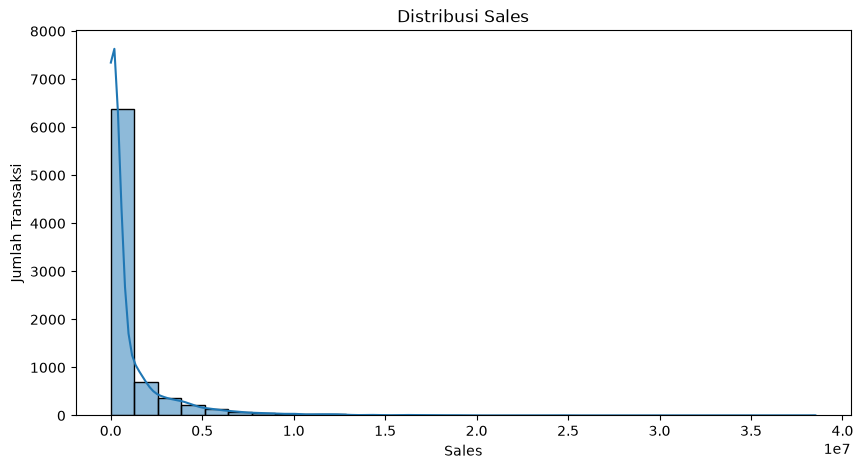

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribusi Sales")
plt.xlabel("Sales")
plt.ylabel("Jumlah Transaksi")

plt.show()

## 3.3 Distribusi Profit

Visualisasi distribusi Profit digunakan untuk memahami persebaran keuntungan yang diperoleh dari setiap transaksi. Analisis ini membantu mengidentifikasi apakah sebagian besar transaksi menghasilkan keuntungan positif atau terdapat transaksi yang mengalami kerugian.

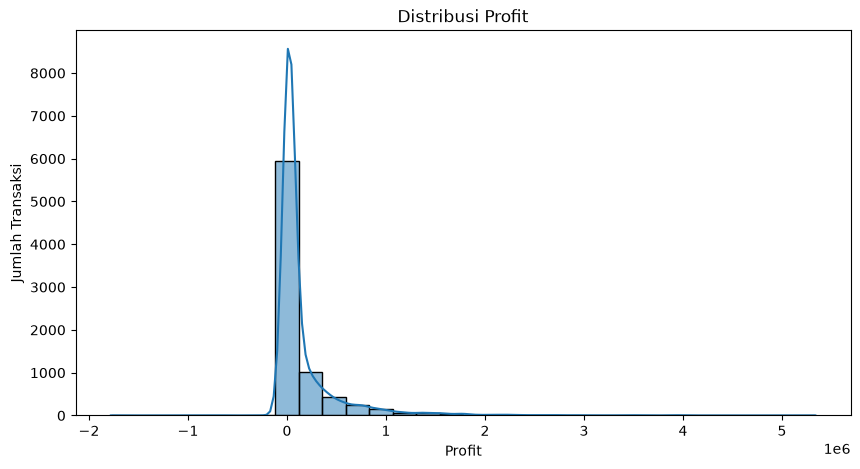

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Distribusi Profit")

plt.xlabel("Profit")

plt.ylabel("Jumlah Transaksi")

plt.show()

In [49]:
print("Tanggal Awal :", df["Order Date"].min())
print("Tanggal Akhir:", df["Order Date"].max())

Tanggal Awal : 2011-01-01 00:00:00
Tanggal Akhir: 2014-12-31 00:00:00


## 3.4 Total Sales Berdasarkan Category

Analisis ini bertujuan untuk mengetahui kategori produk yang memberikan kontribusi terbesar terhadap total penjualan perusahaan.

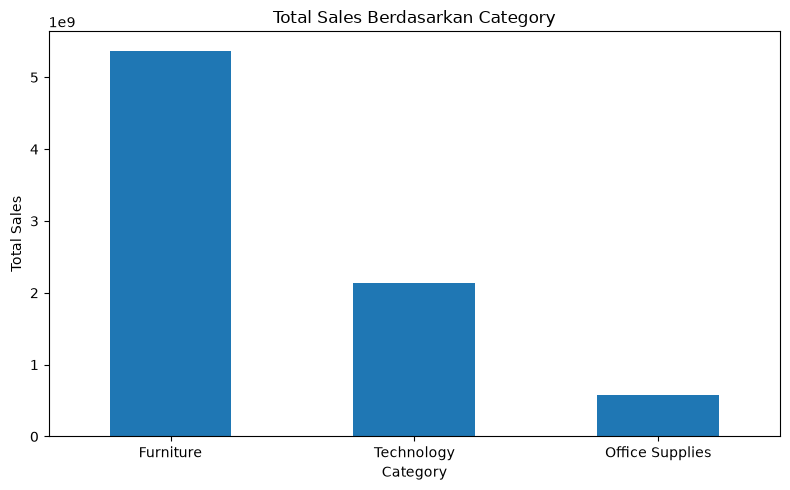

In [53]:
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sales_category.plot(kind="bar")

plt.title("Total Sales Berdasarkan Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.5 Total Profit Berdasarkan Category

Analisis ini digunakan untuk membandingkan total keuntungan yang dihasilkan oleh masing-masing kategori produk.

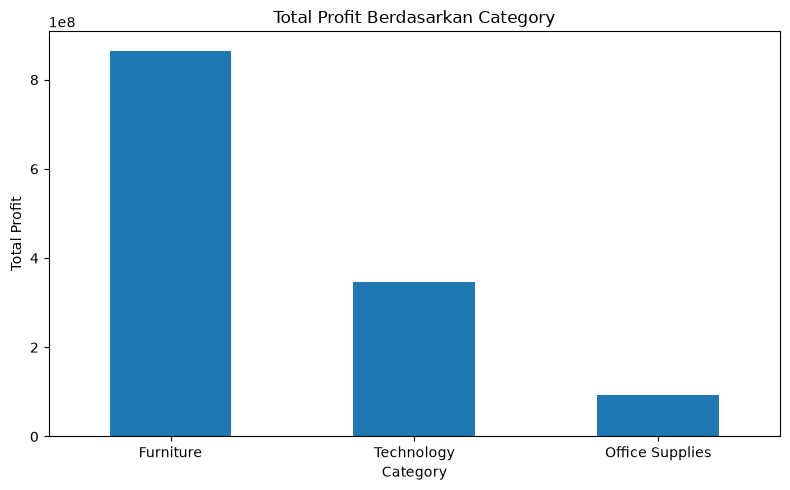

In [54]:
profit_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

profit_category.plot(kind="bar")

plt.title("Total Profit Berdasarkan Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.6 Total Sales Berdasarkan Region

Analisis ini dilakukan untuk membandingkan total penjualan pada setiap wilayah sehingga dapat diketahui wilayah dengan kontribusi penjualan terbesar.

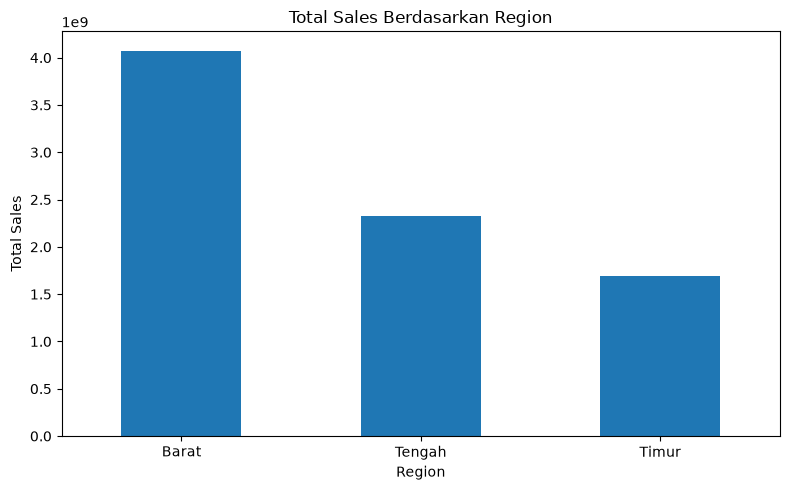

In [55]:
sales_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sales_region.plot(kind="bar")

plt.title("Total Sales Berdasarkan Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.7 Total Sales Berdasarkan Segment

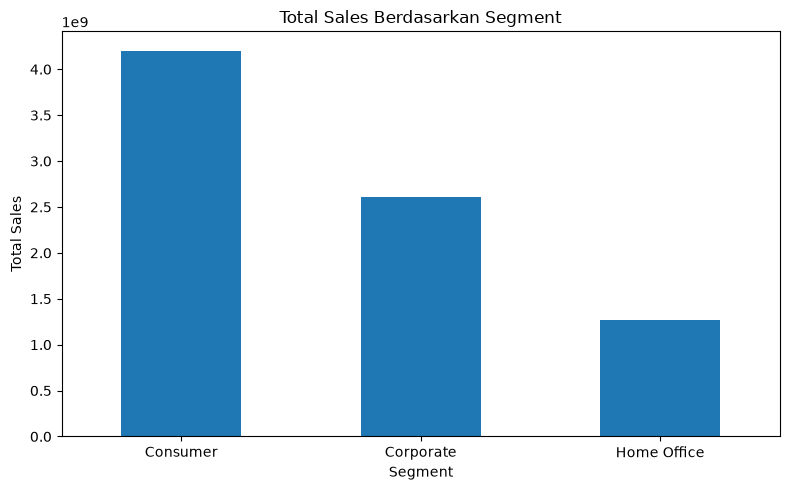

In [56]:
sales_segment = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sales_segment.plot(kind="bar")

plt.title("Total Sales Berdasarkan Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## 3.8 Top 10 Produk Berdasarkan Total Sales

Analisis ini bertujuan untuk mengidentifikasi produk dengan total penjualan tertinggi. Hasil analisis dapat digunakan sebagai dasar dalam menentukan produk unggulan, strategi promosi, serta pengelolaan persediaan.

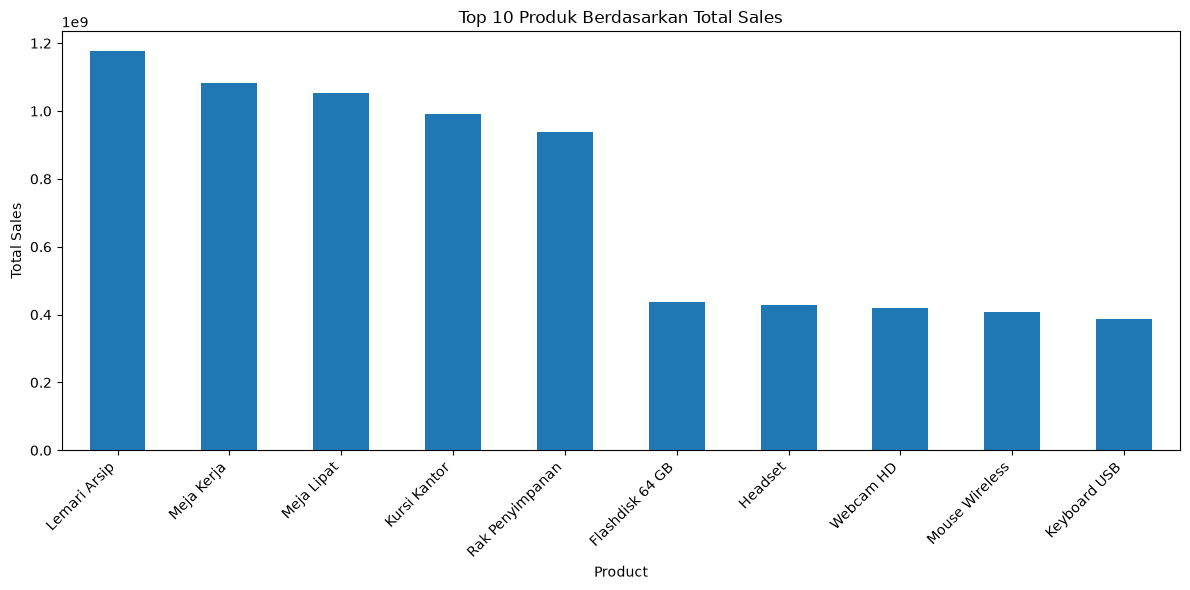

In [57]:
top_product = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_product.plot(kind="bar")

plt.title("Top 10 Produk Berdasarkan Total Sales")

plt.xlabel("Product")

plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

## 3.9 Top 10 Produk Berdasarkan Total Profit

Analisis ini dilakukan untuk mengetahui produk yang memberikan keuntungan terbesar bagi perusahaan.

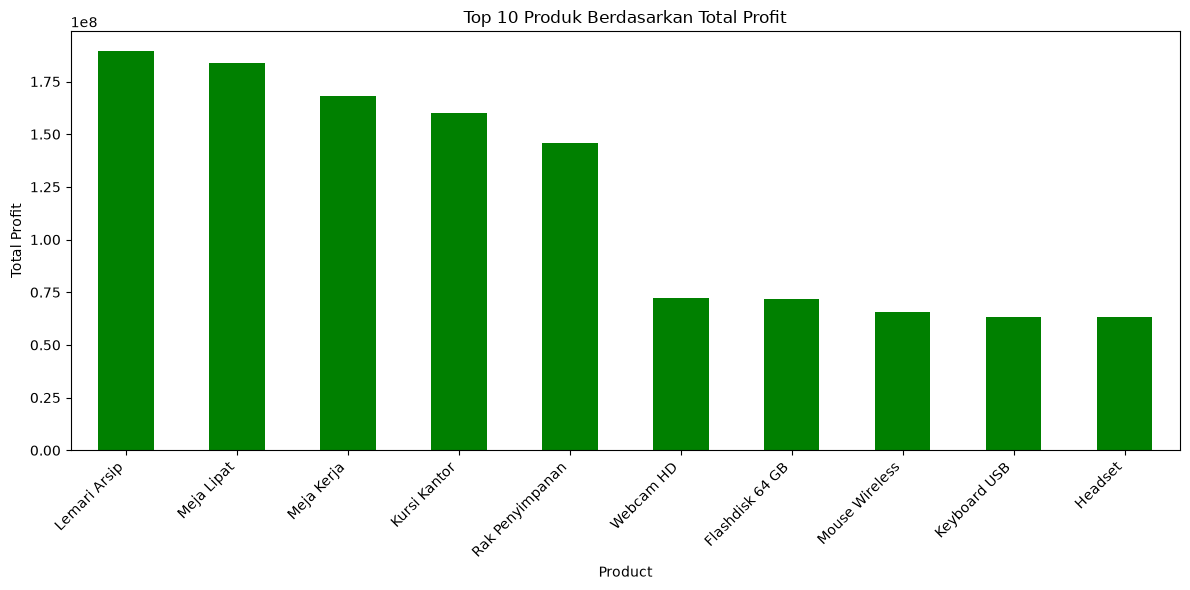

In [58]:
top_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_profit.plot(kind="bar", color="green")

plt.title("Top 10 Produk Berdasarkan Total Profit")

plt.xlabel("Product")

plt.ylabel("Total Profit")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

## 3.10 Hubungan Discount terhadap Profit

Analisis ini bertujuan untuk mengetahui apakah pemberian diskon memiliki hubungan terhadap keuntungan yang diperoleh perusahaan.

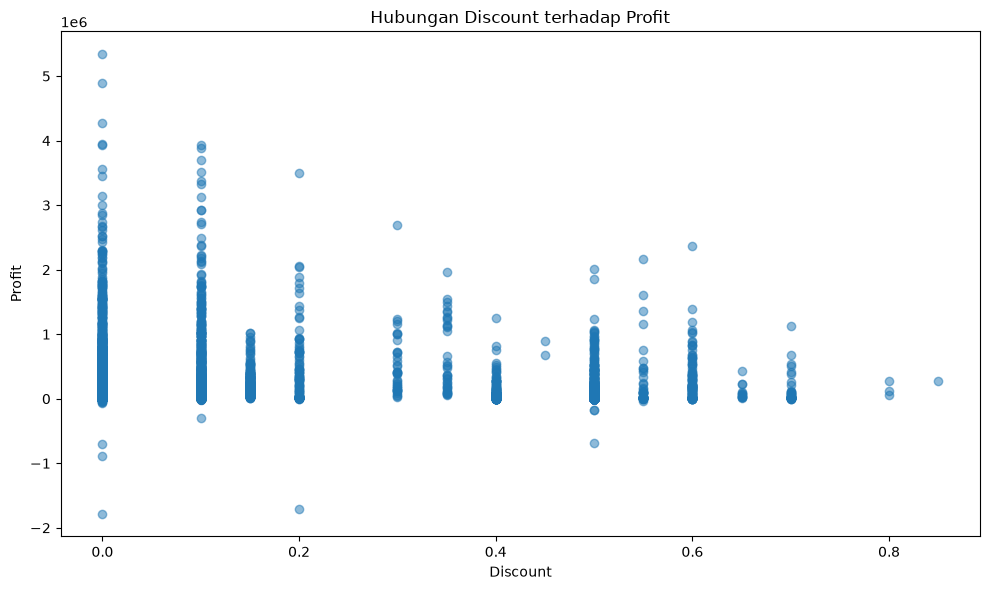

In [59]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Hubungan Discount terhadap Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.tight_layout()

plt.show()

## 3.11 Tren Total Sales per Tahun

Analisis ini dilakukan untuk melihat perubahan total penjualan dari tahun ke tahun selama periode 2011–2014.

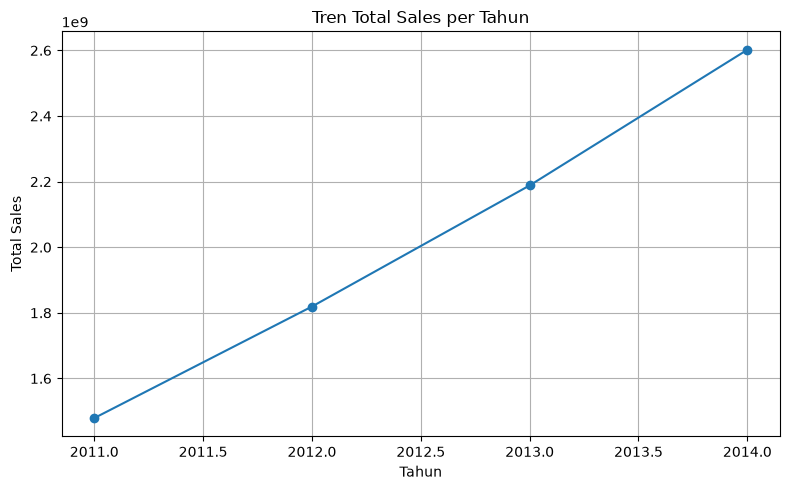

In [60]:
sales_year = (
    df.groupby(df["Order Date"].dt.year)["Sales"]
      .sum()
)

plt.figure(figsize=(8,5))

sales_year.plot(marker="o")

plt.title("Tren Total Sales per Tahun")

plt.xlabel("Tahun")

plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

## 3.12 Tren Total Sales Bulanan

Visualisasi ini digunakan untuk mengidentifikasi pola penjualan setiap bulan selama periode pengamatan.

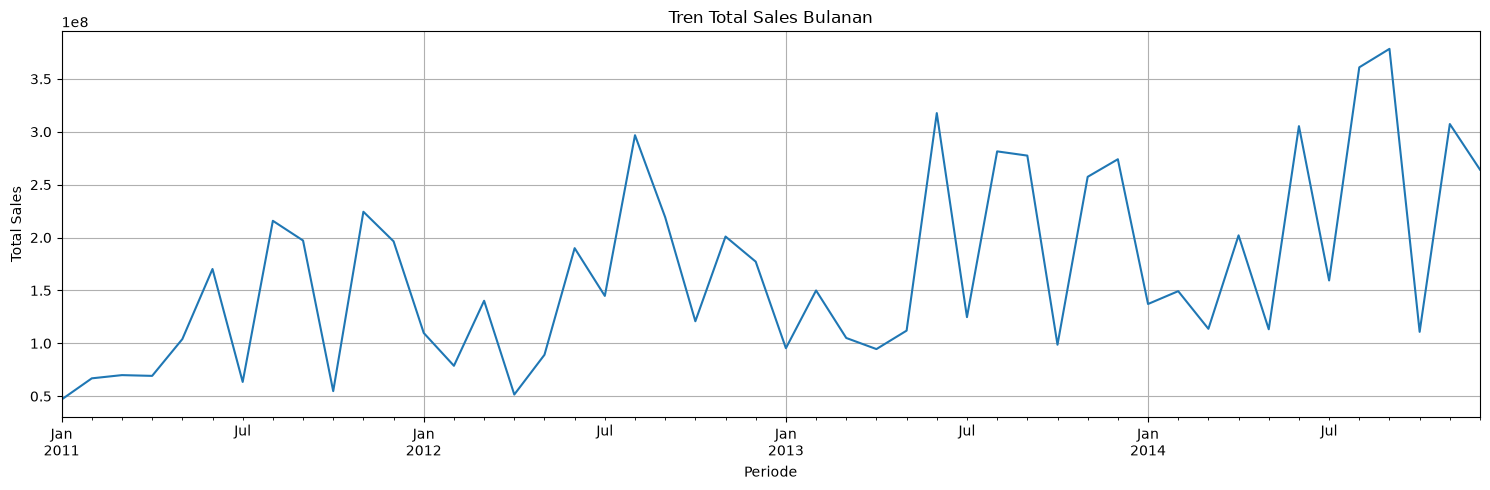

In [61]:
sales_month = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

plt.figure(figsize=(15,5))

sales_month.plot()

plt.title("Tren Total Sales Bulanan")

plt.xlabel("Periode")

plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

Customer Behavior Analysis

In [8]:
df.columns.tolist()

['Order ID',
 'Order Date',
 'Customer Name',
 'Country',
 'State',
 'City',
 'Region',
 'Segment',
 'Ship Mode',
 'Category',
 'Sub-Category',
 'Product Name',
 'Discount',
 'Sales',
 'Profit',
 'Quantity',
 'Feedback?']

In [ ]:
df[["Customer Name", "Sales"]].head()

,Customer Name,Sales
0,Fajar Nugroho,39000
1,Fajar Nugroho,9275000
2,Nurul Hidayah,141000
3,Rizky Hidayat,48500
4,Ahmad Fauzi,10000


In [24]:
#top 10 customer by sales 

top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()

    
)

top_customers["Sales"] = top_customers["Sales"].round(2)

top_customers



,Customer Name,Sales
0,Siti Aisyah,564375000
1,Budi Santoso,554543300
2,Nurul Hidayah,542306750
3,Andi Pratama,542221450
4,Agus Saputra,533541300
5,Ahmad Fauzi,511703150
6,Yusuf Maulana,500475250
7,Nabila Putri,485452900
8,Bagus Setiawan,480865200
9,Putri Maharani,473417350


In [25]:
#visualisasi top 10 customer by sales

import plotly.express as px

fig = px.bar(
    top_customers.sort_values("Sales"),
    x="Sales",
    y="Customer Name",
    orientation="h",
    title="Top 10 Customers by Revenue"
)

fig.show()

In [26]:
# Top 10 Customers by Order Frequency

top_customers_frequency = (
    df.groupby("Customer Name")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Order Frequency")
)

top_customers_frequency

,Customer Name,Order Frequency
0,Bagus Setiawan,489
1,Nurul Hidayah,482
2,Andi Pratama,470
3,Putri Maharani,452
4,Siti Aisyah,451
5,Budi Santoso,447
6,Ahmad Fauzi,445
7,Agus Saputra,443
8,Fajar Nugroho,443
9,Citra Ayuningtyas,442


In [28]:
# Top 10 Customers by Order Frequency

top_customers_frequency = (
    df.groupby("Customer Name")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Order Frequency")
)

fig = px.bar(
    top_customers_frequency.sort_values("Order Frequency"),
    x="Order Frequency",
    y="Customer Name",
    orientation="h",
    title="Top 10 Customers by Order Frequency",
    labels={
        "Order Frequency": "Number of Orders",
        "Customer Name": "Customer"
    },
    text="Order Frequency"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    height=500
)

fig.show()

Profitability / Margin

In [29]:
df[["Sales", "Profit"]].head()

,Sales,Profit
0,39000,7679
1,9275000,2287011
2,141000,14023
3,48500,11246
4,10000,2445


In [30]:
df[["Sales", "Profit"]].dtypes

Sales     int64
Profit    int64
dtype: object

In [31]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 8182479800
Total Profit: 1316668109


In [32]:
# Profit Margin = Total Profit / Total Sales × 100%

profit_margin = (total_profit / total_sales) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 16.09%


In [37]:
# Profitability by Category, Sub-Category & Product

profit_by_product = (
    df.groupby(["Category", "Sub-Category", "Product Name"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

profit_by_product["Profit Margin"] = (
    profit_by_product["Profit"] /
    profit_by_product["Sales"] * 100
).round(2)

profit_by_product = profit_by_product.sort_values(
    "Profit",
    ascending=False
)

profit_by_product.head(20)

,Category,Sub-Category,Product Name,Sales,Profit,Profit Margin
12,Furniture,Chairs,Lemari Arsip,436652500,70135258,16.06
30,Furniture,Furnishings,Meja Lipat,373670000,66670270,17.84
0,Furniture,Bookcases,Kursi Kantor,399280000,65312309,16.36
28,Furniture,Furnishings,Meja Kerja,418452500,63006900,15.06
6,Furniture,Bookcases,Meja Lipat,363880000,60768874,16.70
2,Furniture,Bookcases,Lemari Arsip,357705000,57056804,15.95
5,Furniture,Bookcases,Meja Kerja,338342500,55851702,16.51
34,Furniture,Furnishings,Rak Penyimpanan,349150000,55116786,15.79
25,Furniture,Furnishings,Lemari Arsip,339120000,52787881,15.57
15,Furniture,Chairs,Meja Lipat,294290000,52552360,17.86


### Insight

Visualisasi menunjukkan bahwa transaksi dengan diskon rendah atau tanpa diskon memiliki variasi profit yang lebih besar, termasuk beberapa transaksi dengan keuntungan yang sangat tinggi. Sebaliknya, pada tingkat diskon yang lebih tinggi, profit cenderung berada pada rentang yang lebih rendah dan jarang mencapai nilai yang sangat tinggi.

Selain itu, terdapat beberapa transaksi dengan profit negatif pada berbagai tingkat diskon. Hal ini menunjukkan bahwa profit tidak hanya dipengaruhi oleh besarnya diskon, tetapi kemungkinan juga dipengaruhi oleh faktor lain seperti kategori produk, harga pokok, dan jumlah pembelian. Oleh karena itu, diperlukan analisis lanjutan untuk memahami faktor-faktor yang memengaruhi profit secara lebih menyeluruh.

## 3.13 Korelasi Variabel Numerik

Analisis korelasi dilakukan untuk mengukur hubungan antar variabel numerik dalam dataset. Nilai korelasi berada pada rentang -1 hingga 1, di mana:

- Nilai mendekati **1** menunjukkan hubungan positif yang kuat.
- Nilai mendekati **-1** menunjukkan hubungan negatif yang kuat.
- Nilai mendekati **0** menunjukkan hubungan yang lemah atau tidak terdapat hubungan linear.

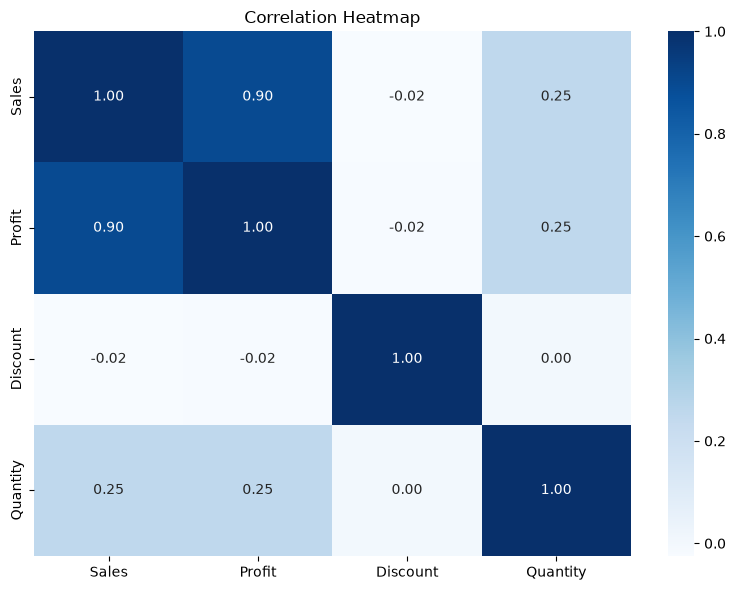

In [62]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Sales","Profit","Discount","Quantity"]].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

### Insight dari heatmap

Correlation Heatmap menunjukkan bahwa **Sales** memiliki hubungan positif yang sangat kuat dengan **Profit** (0,90). Hal ini menunjukkan bahwa peningkatan nilai penjualan umumnya diikuti oleh peningkatan keuntungan perusahaan.

Sebaliknya, **Discount** memiliki korelasi yang sangat lemah terhadap **Sales** (-0,02) maupun **Profit** (-0,02). Hasil ini menunjukkan bahwa besarnya diskon saja tidak cukup untuk menjelaskan perubahan penjualan maupun keuntungan. Kemungkinan terdapat faktor lain seperti kategori produk, harga produk, atau jumlah pembelian yang turut memengaruhi profitabilitas.

Selain itu, **Quantity** memiliki hubungan positif yang lemah terhadap Sales dan Profit (0,25), yang menunjukkan bahwa jumlah barang yang terjual bukan satu-satunya faktor yang menentukan besarnya penjualan maupun keuntungan.

# Business Insight

Berdasarkan hasil Exploratory Data Analysis (EDA), diperoleh beberapa insight yang dapat digunakan sebagai dasar dalam mendukung pengambilan keputusan bisnis.

### 1. Penjualan Mengalami Pertumbuhan Setiap Tahun

Tren total penjualan menunjukkan peningkatan yang konsisten selama periode 2011 hingga 2014. Total Sales meningkat setiap tahun tanpa mengalami penurunan, yang mengindikasikan bahwa performa bisnis terus berkembang selama periode pengamatan.

### 2. Furniture Menjadi Kategori dengan Profit Tertinggi

Analisis berdasarkan kategori menunjukkan bahwa Furniture menghasilkan total profit terbesar dibandingkan Technology maupun Office Supplies. Hal ini menunjukkan bahwa kategori Furniture memberikan kontribusi keuntungan paling besar terhadap perusahaan.

### 3. Sales Memiliki Hubungan Positif yang Sangat Kuat dengan Profit

Correlation Heatmap menunjukkan bahwa Sales memiliki korelasi sebesar **0,90** terhadap Profit. Hal ini menunjukkan bahwa peningkatan nilai penjualan umumnya diikuti oleh peningkatan keuntungan perusahaan.

### 4. Discount Bukan Faktor Utama yang Menentukan Profit

Analisis korelasi menunjukkan bahwa Discount hanya memiliki korelasi sebesar **-0,02** terhadap Profit. Nilai tersebut menunjukkan hubungan linear yang sangat lemah, sehingga perubahan profit kemungkinan lebih dipengaruhi oleh faktor lain seperti kategori produk, harga jual, atau biaya.

### 5. Jumlah Barang Terjual Bukan Satu-satunya Penentu Penjualan

Quantity memiliki korelasi sebesar **0,25** terhadap Sales maupun Profit. Hal ini menunjukkan bahwa peningkatan jumlah barang yang terjual belum tentu menghasilkan peningkatan penjualan atau keuntungan yang signifikan karena masih dipengaruhi oleh nilai dan jenis produk yang dijual.

### 5. Penjualan Bulanan Berfluktuasi

Meskipun tren tahunan menunjukkan peningkatan yang konsisten, total penjualan bulanan mengalami fluktuasi yang cukup besar. Beberapa bulan menunjukkan lonjakan penjualan yang tinggi, sedangkan bulan lainnya mengalami penurunan. Hal ini mengindikasikan adanya pola musiman atau faktor tertentu yang memengaruhi penjualan pada periode tertentu.

# Kesimpulan

Berdasarkan hasil Exploratory Data Analysis (EDA), dapat disimpulkan bahwa perusahaan menunjukkan pertumbuhan penjualan yang konsisten selama periode 2011–2014. Region Barat merupakan wilayah dengan kontribusi penjualan terbesar, sedangkan kategori Furniture memberikan kontribusi profit tertinggi.

Analisis juga menunjukkan bahwa sebagian besar produk dengan profit tertinggi berasal dari kategori Furniture, sehingga kategori ini memiliki peran penting terhadap profitabilitas perusahaan. Selain itu, meskipun penjualan tahunan terus meningkat, penjualan bulanan masih mengalami fluktuasi yang cukup signifikan.

Dari sisi hubungan antar variabel, Sales memiliki hubungan positif yang sangat kuat dengan Profit (korelasi 0,90), sedangkan Discount memiliki hubungan linear yang sangat lemah terhadap Profit. Hal ini menunjukkan bahwa peningkatan profit perusahaan tidak hanya dipengaruhi oleh kebijakan diskon, tetapi juga oleh faktor lain seperti kategori produk, harga, dan karakteristik transaksi.